# rLSI mapping on reference atlas

In [1]:
suppressPackageStartupMessages({ # this first line makes sure you don't get all the start up messages
    library(data.table) # used for manipulating data
    library(dplyr) # used for the 'pipes'
    library(ggplot2) # used for plotting data
    library(Seurat)
    library(SingleCellExperiment)
    library(dplyr)
    library(Signac)
    #library(SingleR)
    library(RColorBrewer)
    library(future)
})

In [2]:
plan("multicore", workers = 16)
options(future.globals.maxSize = 50 * 1024 ^ 3) # for 50 Gb RAM

In [3]:
# We want to specify as many variables as possible in the very beginning and as few as possible in the actual code
# If you do this, you can reproduce your code for other projects with only having to change the variables in the first block
# Otherwise, you will have to go through the whole code and change all places that have certain variables

io = list() # here we make an object called 'io', standing for input/output, which is an empty list
# now we are going to assign paths to files to this io list
io$main = "/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood" # this is the main directory

#Specify paths to HE multiome files
io$multiome_HE_metadata = file.path(io$main, "results/atac/archR/qc/sample_metadata_after_qc.txt.gz") # This specifies to a location within the main folder
io$multiome_HE_peakmatrix = file.path(io$main, "processed/atac/archR/Matrices/PeakMatrix_atlas_summarized_experiment.rds")

#Specify paths to reference atlas
io$multiome_atlas =  "/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation_multiome"
io$multiome_peakmatrix = file.path(io$multiome_atlas, "data/processed/atac/archR/Matrices/PeakMatrix_summarized_experiment.rds")
io$multiome_metadata = file.path(io$multiome_atlas, "results/atac/archR/qc/sample_metadata_after_qc.txt.gz")

#outdir
io$outdir = file.path(io$main, '/results/multiome_atlas_integration/atac/')

### load data

In [4]:
#Load in Metadata for In Vitro 
vitro_metadata = fread(io$multiome_HE_metadata)[pass_atacQC == TRUE & doublet_call==FALSE]

# Load in In Vitro Seurat Object (Multiome Project)
vitro.peakmatrix = readRDS(io$multiome_HE_peakmatrix)
vitro.peakmatrix = vitro.peakmatrix[,vitro_metadata$cell]

In [5]:
#Load in Metadata for multiome Reference
altas_metadata = fread(io$multiome_metadata)[pass_atacQC == TRUE & doublet_call==FALSE & !sample %in% c('E8.5_CRISPR_T_KO', 'E8.5_CRISPR_T_WT')]

# Load in multiome Mouse Gastrulation Atlas SCE Object (Reference Atlas)
atlas.peakmatrix = readRDS(io$multiome_peakmatrix)
atlas.peakmatrix = atlas.peakmatrix[,altas_metadata$cell]

### Create seurat objects

In [6]:
##########################
## In vitro HE multiome ##
##########################

# Extract counts
vitro.counts = vitro.peakmatrix@assays@data$PeakMatrix_atlas
rownames(vitro.counts) = rownames(vitro.peakmatrix)

# create object
vitro.atac <- CreateSeuratObject(counts = vitro.counts, assay = "peaks")

# compute LSI
vitro.atac <- FindTopFeatures(vitro.atac, min.cutoff = 10)
vitro.atac <- RunTFIDF(vitro.atac)
vitro.atac <- RunSVD(vitro.atac, n = 35)

Performing TF-IDF normalization

Warning message in RunTFIDF.default(object = GetAssayData(object = object, slot = "counts"), :
“Some features contain 0 total counts”
Running SVD

Scaling cell embeddings



Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”


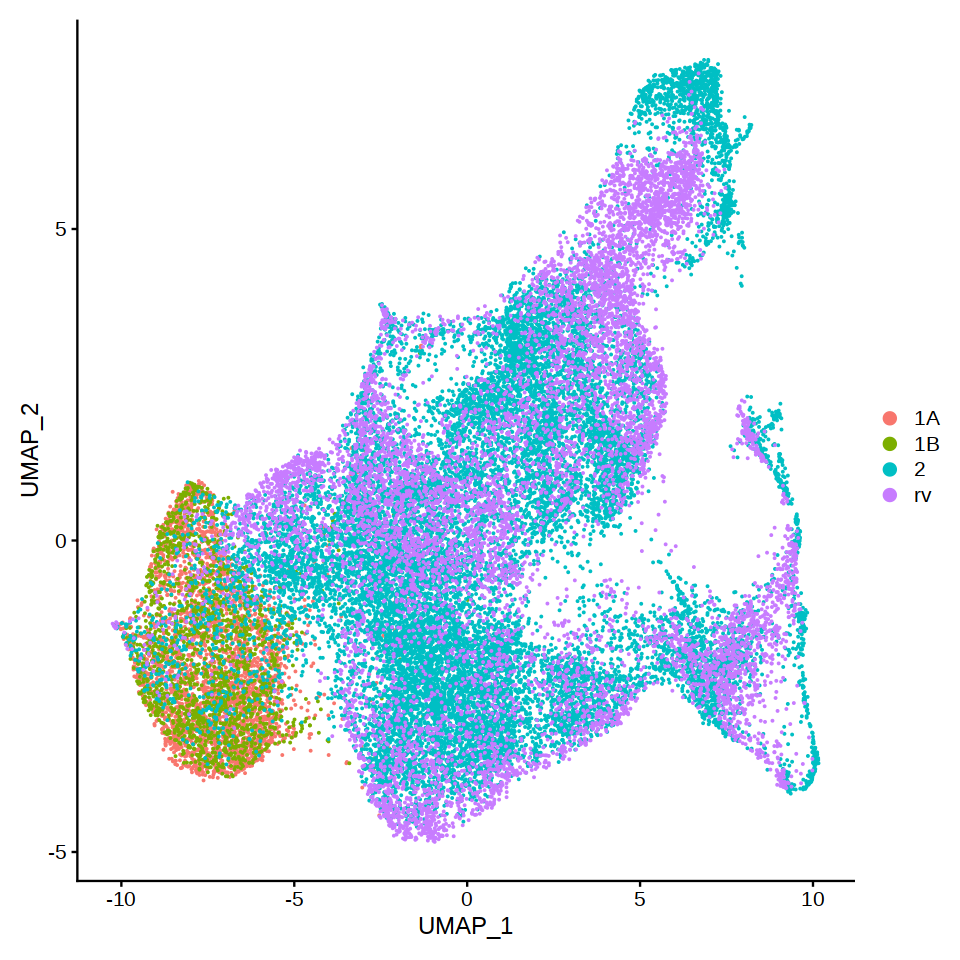

In [7]:
# Plot
vitro.atac <- RunUMAP(vitro.atac, reduction = "lsi", dims = 2:20, verbose=FALSE)
options(repr.plot.width=8, repr.plot.height=8)
DimPlot(vitro.atac)

In [8]:
LSI_depth.corr = lapply(1:dim(vitro.atac@reductions$lsi@cell.embeddings)[2], function(x){
    tmp = cor(vitro.atac@reductions$lsi@cell.embeddings[,x], vitro.atac@meta.data$nCount_peaks)
    return(tmp)
}) %>% unlist()
names(LSI_depth.corr) = colnames(vitro.atac@reductions$lsi@cell.embeddings)
head(LSI_depth.corr[order(-abs(LSI_depth.corr))])

LSI_1      LSI_5      LSI_2      LSI_4     LSI_13     LSI_12 
 0.9385659 -0.7635226  0.2985516 -0.1937382  0.1728192 -0.1497013

In [9]:
############################
## In vivo atlas multiome ##
############################

# Extract counts
atlas.counts = atlas.peakmatrix@assays@data$PeakMatrix
rownames(atlas.counts) = rownames(atlas.peakmatrix)

# create object
atlas.atac <- CreateSeuratObject(counts = atlas.counts, assay = "peaks")

# compute LSI
atlas.atac <- FindTopFeatures(atlas.atac, min.cutoff = 10)
atlas.atac <- RunTFIDF(atlas.atac)
atlas.atac <- RunSVD(atlas.atac, n = 35)

Performing TF-IDF normalization

Running SVD

Scaling cell embeddings



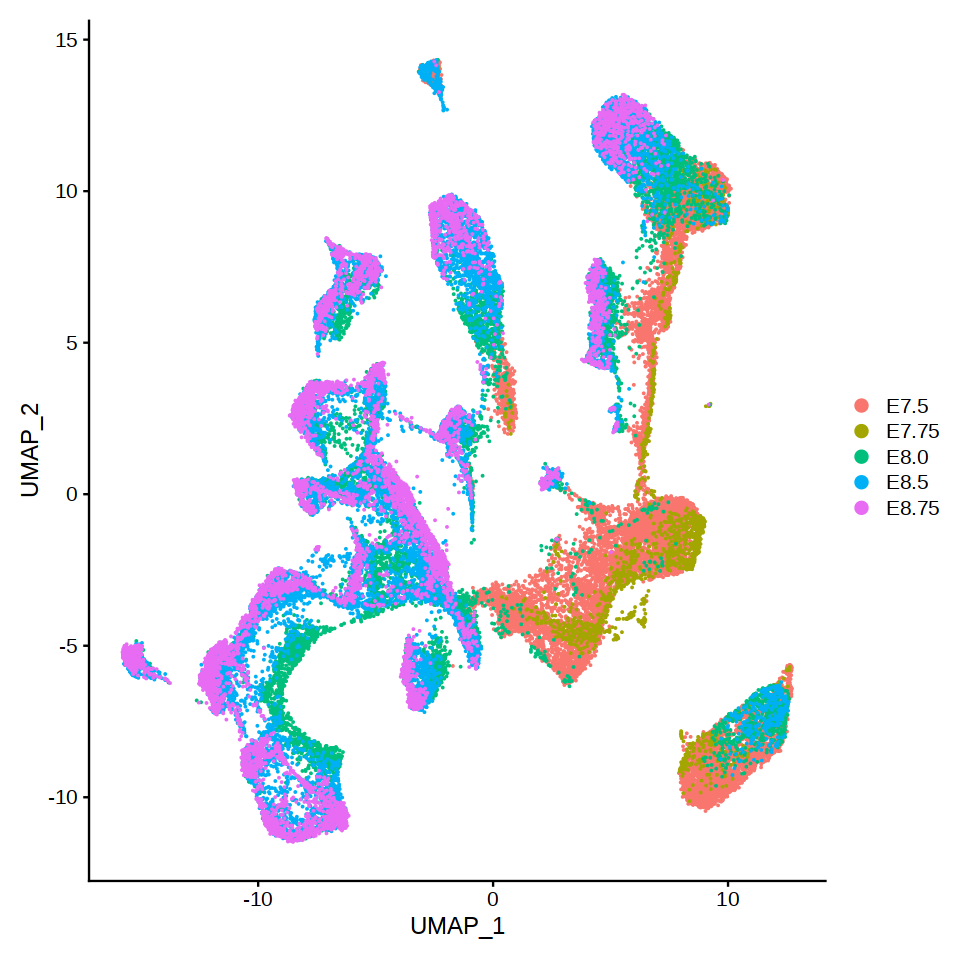

In [10]:
# Plot
atlas.atac <- RunUMAP(atlas.atac, reduction = "lsi", dims = 2:35, verbose=FALSE)
options(repr.plot.width=8, repr.plot.height=8)
DimPlot(atlas.atac)

In [11]:
LSI_depth.corr = lapply(1:dim(atlas.atac@reductions$lsi@cell.embeddings)[2], function(x){
    tmp = cor(atlas.atac@reductions$lsi@cell.embeddings[,x], atlas.atac@meta.data$nCount_peaks)
    return(tmp)
}) %>% unlist()
names(LSI_depth.corr) = colnames(atlas.atac@reductions$lsi@cell.embeddings)
head(LSI_depth.corr[order(-abs(LSI_depth.corr))])

LSI_1      LSI_9     LSI_11     LSI_13     LSI_16      LSI_2 
-0.9452188 -0.4349204 -0.3854433  0.3612177  0.2284454 -0.2196891

### Integrating the datasets

In [12]:
# first add dataset-identifying metadata
vitro.atac$dataset <- "vitro_HE"
atlas.atac$dataset <- "atlas"

# merge
atac.combined <- merge(atlas.atac, vitro.atac)

# process the combined dataset
atac.combined <- FindTopFeatures(atac.combined, min.cutoff = "q5")
atac.combined <- RunTFIDF(atac.combined)
atac.combined <- RunSVD(atac.combined, n = 35)
atac.combined <- RunUMAP(atac.combined, reduction = "lsi", dims = 2:35, verbose=FALSE) # removes first LSI, but not given that this one actually correlates with nFrags best
p1 <- DimPlot(atac.combined, group.by = "dataset")

Performing TF-IDF normalization

Running SVD

Scaling cell embeddings



In [13]:
plan("multicore", workers = 1)

In [14]:
atlas.atac
vitro.atac

An object of class Seurat 
192251 features across 45887 samples within 1 assay 
Active assay: peaks (192251 features, 192251 variable features)
 2 dimensional reductions calculated: lsi, umap

An object of class Seurat 
192251 features across 33177 samples within 1 assay 
Active assay: peaks (192251 features, 192147 variable features)
 2 dimensional reductions calculated: lsi, umap

In [15]:
# find integration anchors
integration.anchors <- FindIntegrationAnchors(
  object.list = list(atlas.atac, vitro.atac),
  reference = 1,
  anchor.features = rownames(atlas.atac),
  reduction = "rlsi",
  dims = 2:35 # make sure both datasets have LSI ran with at least this number of dimensions (and possibly both at exactly the same)
)


Computing within dataset neighborhoods

Finding anchors between all query and reference datasets

Projecting new data onto SVD

Projecting new data onto SVD

Finding neighborhoods

Finding anchors

	Found 4317 anchors



In [16]:

# integrate LSI embeddings
integrated <- IntegrateEmbeddings(
  anchorset = integration.anchors,
  reductions = atac.combined[["lsi"]],
  new.reduction.name = "integrated_lsi",
  dims.to.integrate = 1:35
)

# create a new UMAP using the integrated embeddings
integrated <- RunUMAP(integrated, reduction = "integrated_lsi", dims = 2:35, verbose=FALSE)
integrated@meta.data$dataset = atac.combined@meta.data$dataset
p2 <- DimPlot(integrated, group.by = "dataset")

Warning message:
“The following arguments are not used: check.matrix”

Integrating dataset 2 with reference dataset

Finding integration vectors

Finding integration vector weights

Integrating data



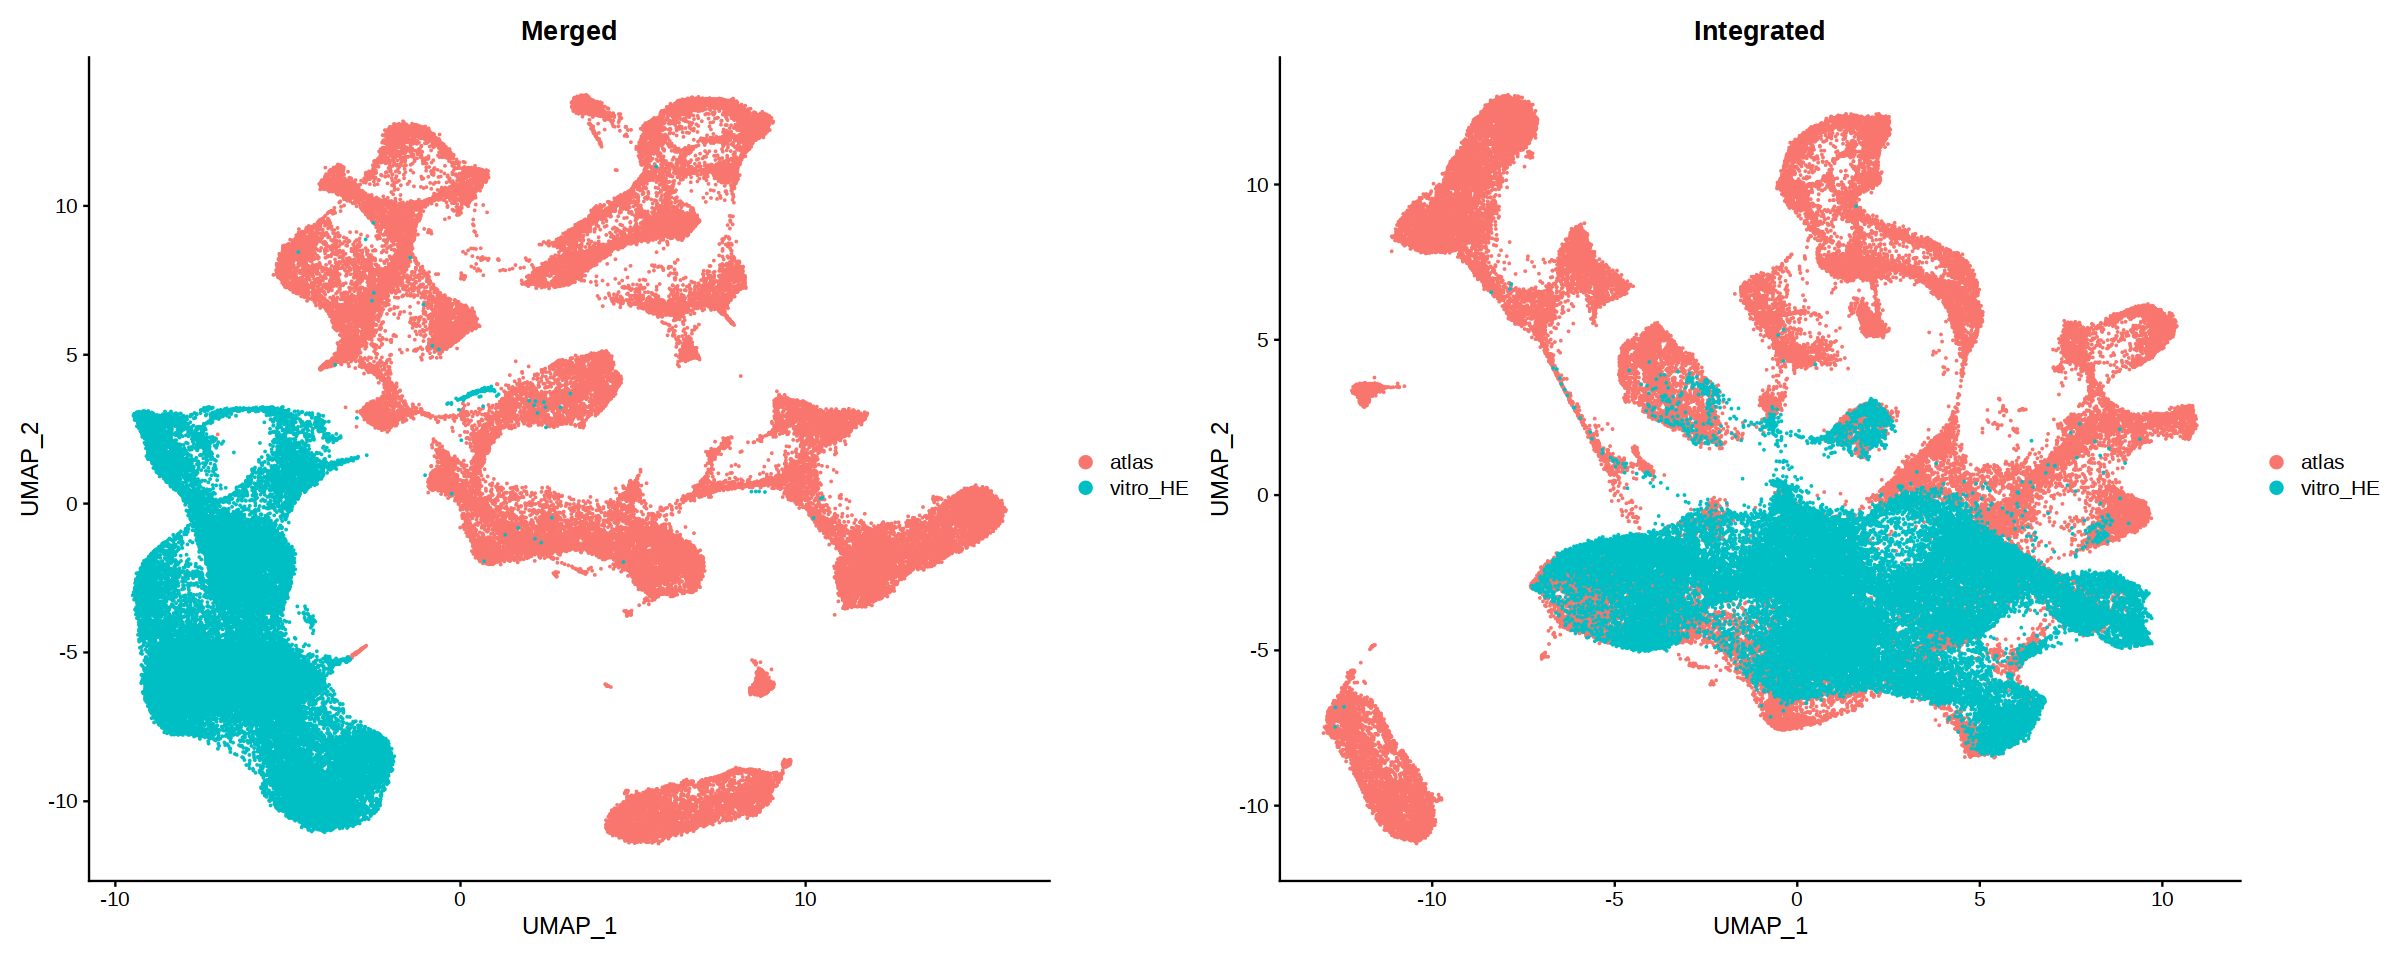

In [17]:
options(repr.plot.width=20, repr.plot.height=8)
(p1 + ggtitle("Merged")) | (p2 + ggtitle("Integrated"))

In [18]:
saveRDS(integrated, sprintf('%s/integrated.rds', io$outdir))

In [20]:
# Save counts & LSI
saveRDS(integrated@assays$peaks@counts, sprintf('%s/atac_counts.rds', io$outdir))

saveRDS(integrated@reductions$integrated_lsi, sprintf('%s/integrated_lsi.rds', io$outdir))

In [21]:
head(integrated@assays$peaks@counts)

  [[ suppressing 34 column names ‘E7.5_rep1#AAACAGCCATCCTGAA-1’, ‘E7.5_rep1#AAACAGCCATGCTATG-1’, ‘E7.5_rep1#AAACATGCAATGAATG-1’ ... ]]



6 x 79064 sparse Matrix of class "dgCMatrix"
                                                                              
chr1:3035602-3036202 . . . . . . . . . . . . . . . . . . . . . 1 . . . . . . .
chr1:3062653-3063253 . . . . . . . . . . . . 2 . 2 . . . . . . . . . . . . . .
chr1:3072313-3072913 . . . . . . . . . . . . . . . . . . . . . . . . . . . . .
chr1:3191496-3192096 . . . . . . . . . . . . . . . . . . . . . 2 . . . . . . .
chr1:3340575-3341175 . . . . . . . . . . . . . . . . . . . . . . . . . . . . .
chr1:3443943-3444543 . . . . . . . . . . . . . . . . . . . . . . . . . . . . .
                                     
chr1:3035602-3036202 . . . . . ......
chr1:3062653-3063253 . . . . . ......
chr1:3072313-3072913 . . . . . ......
chr1:3191496-3192096 . . . . . ......
chr1:3340575-3341175 . . . . . ......
chr1:3443943-3444543 . . . . . ......

 .....suppressing 79030 columns in show(); maybe adjust 'options(max.print= *, width = *)'
 ..............................